In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv


In [2]:
import pandas as pd
data=pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')
data.head()

,incident_id,date,year,incident_type,category,latitude,longitude,weather_condition,suspected_cause,outcome,casualties,search_duration_days,debris_found,reporting_authority,confidence_level,data_type
0,1,2003-02-20,2003,Accident,Air,30.1183,-70.8068,Clear,Human Error,Resolved,1,4.7,No,NOAA,Medium,Simulated (Distribution-Based)
1,2,2024-03-11,2024,Accident,Sea,23.9463,-70.6564,Cloudy,Technical Failure,Debris Found,0,7.8,Yes,FAA,Medium,Simulated (Distribution-Based)
2,3,2017-02-17,2017,Accident,Air,25.6513,-71.2984,Clear,Human Error,Debris Found,1,5.9,Yes,Maritime Authority,High,Simulated (Distribution-Based)
3,4,2012-01-19,2012,Disappearance,Air,27.8192,-73.3295,Clear,Human Error,Minor Damage,3,2.3,No,FAA,Low,Simulated (Distribution-Based)
4,5,1991-09-19,1991,Navigation Failure,Sea,27.5928,-74.1450,Rough Seas,Weather,Resolved,1,18.7,No,FAA,Medium,Simulated (Distribution-Based)


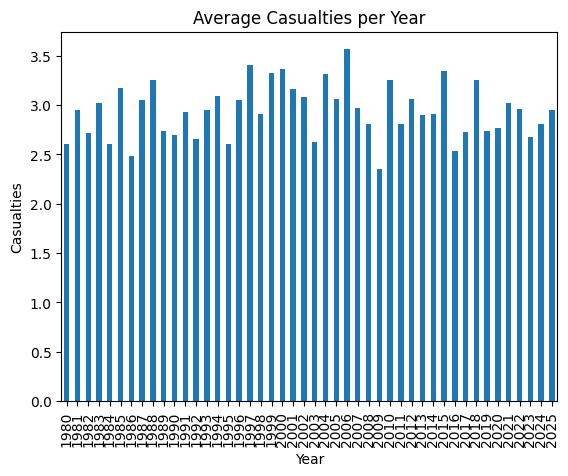

MSE: 7.473975621716694
R2 Score: -0.004805527243869401


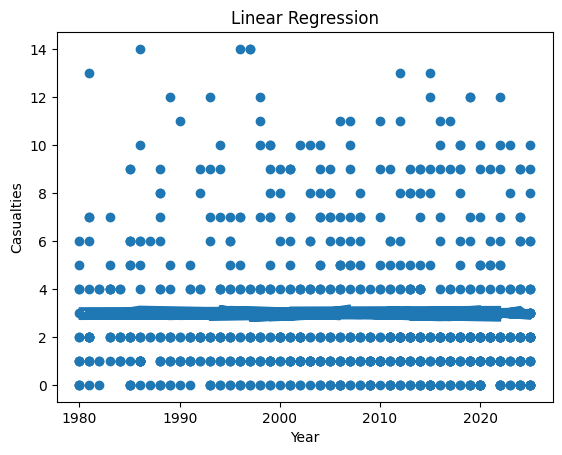

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')

# Clean column names
data.columns = data.columns.str.strip()

# Features and Target (FIXED)
# -----------------------------
X = data[['year', 'latitude', 'longitude', 'search_duration_days']]
y = data['casualties']

data.columns = data.columns.str.strip()

data.groupby('year')['casualties'].mean().plot(kind='bar')

plt.title("Average Casualties per Year")
plt.xlabel("Year")
plt.ylabel("Casualties")
plt.show()
# -----------------------------
# Handle Missing Values
# -----------------------------
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# -----------------------------
# Train-Test Split
# -----------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -----------------------------
# Linear Regression
# -----------------------------
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# -----------------------------
# Visualization
# -----------------------------
plt.scatter(X_test['year'], y_test)
plt.plot(X_test['year'], y_pred)
plt.xlabel("Year")
plt.ylabel("Casualties")
plt.title("Linear Regression")
plt.show()

Number of Incidents by Transport Type:

incident_type
Accident              2343
Distress Signal       1011
Disappearance          881
Navigation Failure     765
Name: count, dtype: int64

Total Incidents: 5000


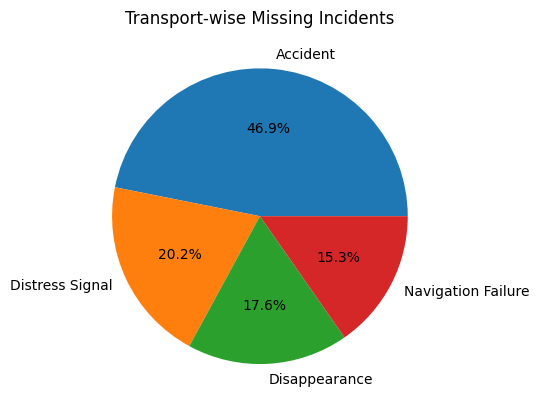

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')

# Clean column names
data.columns = data.columns.str.strip()

# -----------------------------
# Count transport types
# -----------------------------
transport_counts = data['incident_type'].value_counts()

# -----------------------------
# Command Line Output
# -----------------------------
print("Number of Incidents by Transport Type:\n")
print(transport_counts)

print("\nTotal Incidents:", transport_counts.sum())

# -----------------------------
# Pie Chart
# -----------------------------
plt.figure()

transport_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Transport-wise Missing Incidents")
plt.ylabel("")  # removes extra label
plt.show()

Signal Loss Analysis:

signal_loss
False    2758
True     2242
Name: count, dtype: int64


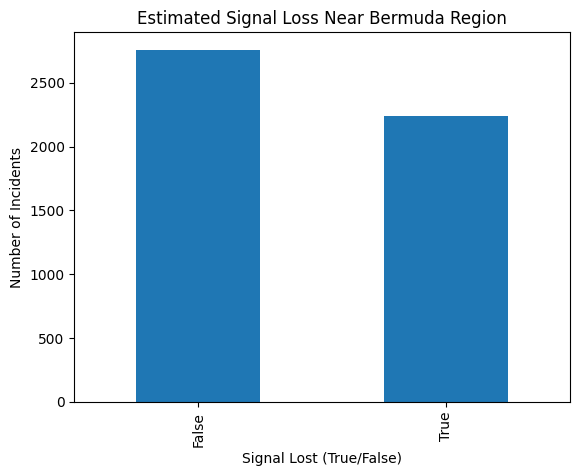

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')

data.columns = data.columns.str.strip()

# Bermuda Triangle center
center_lat = 25.0
center_lon = -71.0

# Convert degrees to radians
lat1 = np.radians(center_lat)
lon1 = np.radians(center_lon)
lat2 = np.radians(data['latitude'])
lon2 = np.radians(data['longitude'])

# Haversine formula
dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

# Earth radius (km)
R = 6371

# Distance
data['distance_from_center'] = R * c

# -----------------------------
# Assume signal loss threshold
# -----------------------------
# Example: signal cuts if distance < 300 km
data['signal_loss'] = data['distance_from_center'] < 300

# -----------------------------
# Count signal loss cases
# -----------------------------
signal_counts = data['signal_loss'].value_counts()

print("Signal Loss Analysis:\n")
print(signal_counts)

# -----------------------------
# Plot  
# -----------------------------
signal_counts.plot(kind='bar')

plt.title("Estimated Signal Loss Near Bermuda Region")
plt.xlabel("Signal Lost (True/False)")
plt.ylabel("Number of Incidents")
plt.show()

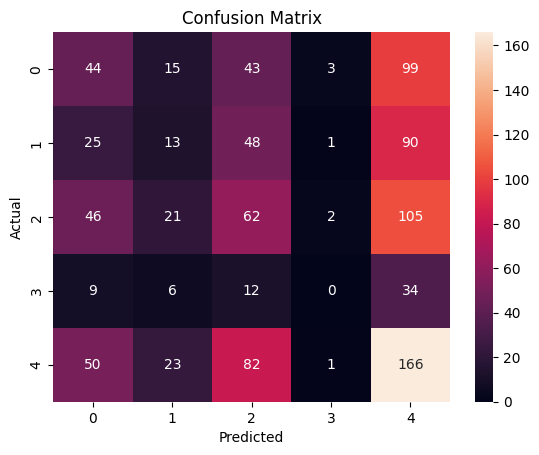

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')

data.columns = data.columns.str.strip()

# -----------------------------
# Convert outcome to numeric
# -----------------------------
data['outcome'] = data['outcome'].astype('category').cat.codes

# -----------------------------
# Features and Target
# -----------------------------
X = data[['year', 'latitude', 'longitude', 'search_duration_days']].fillna(0)
y = data['outcome']

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# -----------------------------
# Model
# -----------------------------
model = RandomForestClassifier()
model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

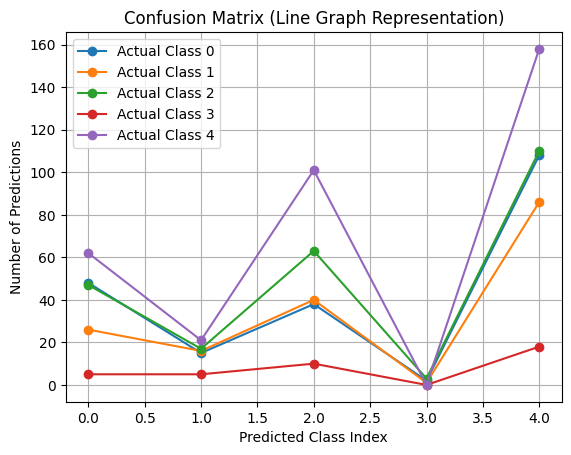

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/sarcasmos/bermuda-triangle-incidents-19802025/bermuda_triangle_incidents_1980_2025.csv')

data.columns = data.columns.str.strip()

# Convert outcome to numeric
data['outcome'] = data['outcome'].astype('category').cat.codes

# Features and Target
X = data[['year', 'latitude', 'longitude', 'search_duration_days']].fillna(0)
y = data['outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# -----------------------------
# Line Graph Visualization
# -----------------------------
plt.figure()

for i in range(len(cm)):
    plt.plot(range(len(cm[i])), cm[i], marker='o', label=f'Actual Class {i}')

plt.title("Confusion Matrix (Line Graph Representation)")
plt.xlabel("Predicted Class Index")
plt.ylabel("Number of Predictions")
plt.legend()
plt.grid()

plt.show()